<a href="https://colab.research.google.com/github/arzmtva/my-data-analysis/blob/main/%D0%9A%D0%BE%D0%BF%D0%B8%D1%8F_%D0%B1%D0%BB%D0%BE%D0%BA%D0%BD%D0%BE%D1%82%D0%B0_%22Practical_Work_4_Regression%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.stats.outliers_influence import variance_inflation_factor


In [ ]:
data = fetch_california_housing(as_frame=True)

df = data.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [ ]:
print("Размер датасета:", df.shape)

print("\nНазвания признаков:")
print(df.columns)

print("\nИнформация:")
print(df.info())

Размер датасета: (20640, 9)

Названия признаков:
Index(['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup',
       'Latitude', 'Longitude', 'MedHouseVal'],
      dtype='object')

Информация:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None


In [ ]:
print(df.isnull().sum())

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [ ]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Признаки:")
print(X.columns.tolist())

print("\nРазмер X:", X.shape)
print("Размер y:", y.shape)

Признаки:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Размер X: (20640, 8)
Размер y: (20640,)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Обучающая выборка:", X_train.shape)
print("Тестовая выборка:", X_test.shape)

Обучающая выборка: (16512, 8)
Тестовая выборка: (4128, 8)


In [ ]:
model_base = LinearRegression()

model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

In [ ]:
mae_base = mean_absolute_error(y_test, y_pred_base)
mse_base = mean_squared_error(y_test, y_pred_base)
rmse_base = np.sqrt(mse_base)
r2_base = r2_score(y_test, y_pred_base)

print("БАЗОВАЯ МОДЕЛЬ")
print("-------------------------")
print("MAE :", mae_base)
print("MSE :", mse_base)
print("RMSE:", rmse_base)
print("R²  :", r2_base)

БАЗОВАЯ МОДЕЛЬ
-------------------------
MAE : 0.5332001304956553
MSE : 0.5558915986952444
RMSE: 0.7455813830127764
R²  : 0.5757877060324508


In [ ]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_base.coef_
})

coefficients

,Feature,Coefficient
0,MedInc,0.448675
1,HouseAge,0.009724
2,AveRooms,-0.123323
3,AveBedrms,0.783145
4,Population,-0.000002
5,AveOccup,-0.003526
6,Latitude,-0.419792
7,Longitude,-0.433708


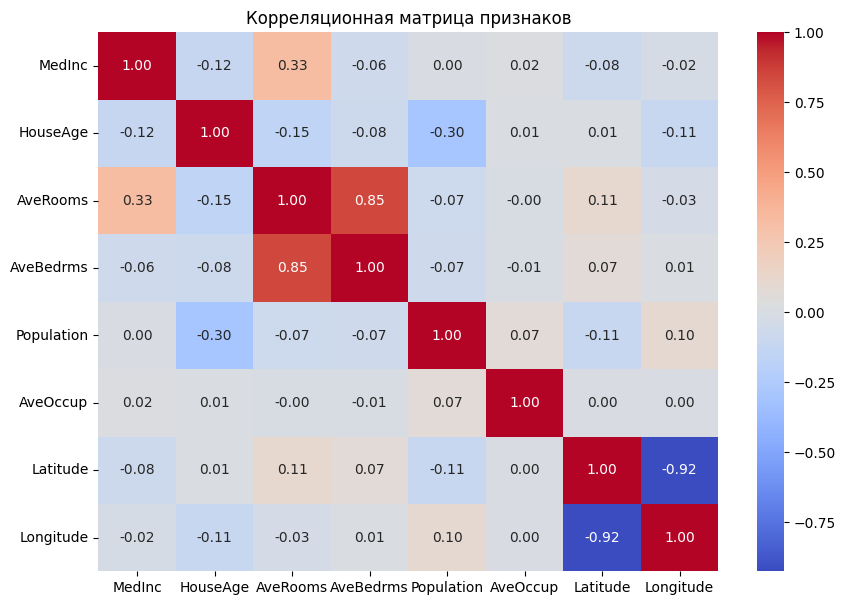

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    X.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляционная матрица признаков")
plt.show()

In [ ]:
corr_matrix = X.corr()

print(corr_matrix.round(2))

            MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
MedInc        1.00     -0.12      0.33      -0.06        0.00      0.02   
HouseAge     -0.12      1.00     -0.15      -0.08       -0.30      0.01   
AveRooms      0.33     -0.15      1.00       0.85       -0.07     -0.00   
AveBedrms    -0.06     -0.08      0.85       1.00       -0.07     -0.01   
Population    0.00     -0.30     -0.07      -0.07        1.00      0.07   
AveOccup      0.02      0.01     -0.00      -0.01        0.07      1.00   
Latitude     -0.08      0.01      0.11       0.07       -0.11      0.00   
Longitude    -0.02     -0.11     -0.03       0.01        0.10      0.00   

            Latitude  Longitude  
MedInc         -0.08      -0.02  
HouseAge        0.01      -0.11  
AveRooms        0.11      -0.03  
AveBedrms       0.07       0.01  
Population     -0.11       0.10  
AveOccup        0.00       0.00  
Latitude        1.00      -0.92  
Longitude      -0.92       1.00  


In [ ]:
vif_data = pd.DataFrame()

vif_data["Feature"] = X.columns

vif_data["VIF"] = [
    variance_inflation_factor(X.values, i)
    for i in range(X.shape[1])
]

vif_data = vif_data.sort_values("VIF", ascending=False)

vif_data

,Feature,VIF
6,Latitude,9.297624
7,Longitude,8.962263
2,AveRooms,8.342786
3,AveBedrms,6.994995
0,MedInc,2.501295
1,HouseAge,1.241254
4,Population,1.138125
5,AveOccup,1.008324


In [ ]:
X_reduced = X.drop("AveBedrms", axis=1)

print("Признаки после сокращения:")
print(X_reduced.columns.tolist())

print("\nКоличество признаков:", X_reduced.shape[1])

Признаки после сокращения:
['MedInc', 'HouseAge', 'AveRooms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Количество признаков: 7


In [ ]:
X_train_red, X_test_red, y_train_red, y_test_red = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42
)

print("X_train:", X_train_red.shape)
print("X_test:", X_test_red.shape)

X_train: (16512, 7)
X_test: (4128, 7)


In [ ]:
model_reduced = LinearRegression()

model_reduced.fit(X_train_red, y_train_red)

y_pred_red = model_reduced.predict(X_test_red)

In [ ]:
mae_red = mean_absolute_error(y_test_red, y_pred_red)
mse_red = mean_squared_error(y_test_red, y_pred_red)
rmse_red = np.sqrt(mse_red)
r2_red = r2_score(y_test_red, y_pred_red)

print("СОКРАЩЁННАЯ МОДЕЛЬ")
print("-------------------------")
print("MAE :", mae_red)
print("MSE :", mse_red)
print("RMSE:", rmse_red)
print("R²  :", r2_red)

СОКРАЩЁННАЯ МОДЕЛЬ
-------------------------
MAE : 0.5425438932554485
MSE : 0.5473264990498136
RMSE: 0.7398151789804083
R²  : 0.5823239094526445


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Base model", "Reduced model"],
    "Features": [X.shape[1], X_reduced.shape[1]],
    "MAE": [mae_base, mae_red],
    "MSE": [mse_base, mse_red],
    "RMSE": [rmse_base, rmse_red],
    "R2": [r2_base, r2_red]
})

comparison

,Model,Features,MAE,MSE,RMSE,R2
0,Base model,8,0.533200,0.555892,0.745581,0.575788
1,Reduced model,7,0.542544,0.547326,0.739815,0.582324


In [ ]:
residuals = y_test_red - y_pred_red

print(residuals.head())

20046   -0.258589
3024    -1.292606
15663    2.529884
20484   -0.698449
9814     0.065634
Name: MedHouseVal, dtype: float64


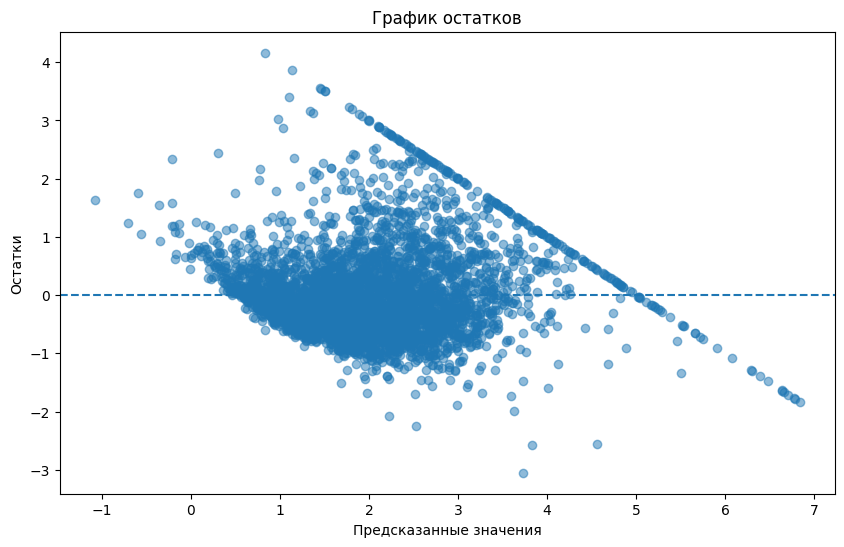

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_red,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")

plt.show()

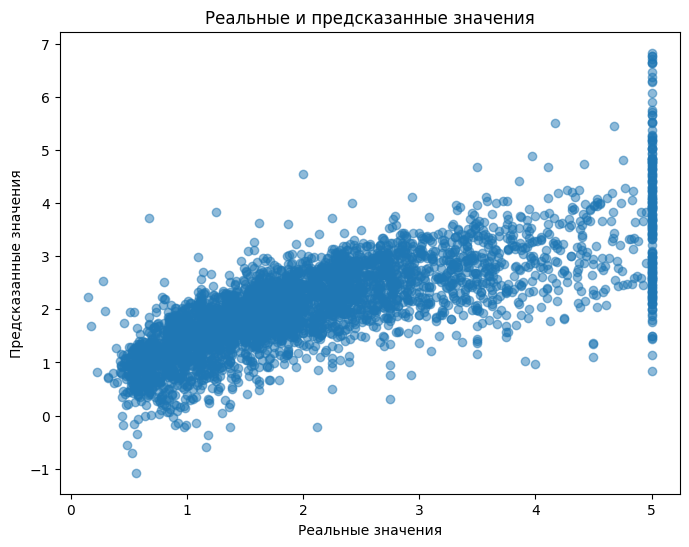

In [ ]:
plt.figure(figsize=(8, 6))

plt.scatter(
    y_test_red,
    y_pred_red,
    alpha=0.5
)

plt.xlabel("Реальные значения")
plt.ylabel("Предсказанные значения")
plt.title("Реальные и предсказанные значения")

plt.show()

## Вывод
В данной работе была построена базовая модель линейной регрессии с использованием всех доступных числовых признаков California Housing Dataset. Качество модели было оценено с помощью MAE, MSE, RMSE и R².

Для проверки мультиколлинеарности была построена корреляционная матрица и рассчитан показатель VIF. На основании полученных результатов был сокращён набор признаков путём удаления избыточного признака.

После этого была обучена вторая модель на сокращённом наборе признаков. Метрики базовой и сокращённой моделей были сравнены. Если качество сокращённой модели осталось примерно на том же уровне, можно сделать вывод, что удалённый признак не вносил существенного дополнительного вклада в предсказание.

Анализ графика остатков показал, насколько случайно распределены ошибки относительно нулевой линии. Отсутствие выраженного систематического паттерна является признаком того, что линейная модель не имеет очевидного нарушения данного допущения.

Таким образом, финальный набор признаков был выбран с учётом одновременно качества модели и отсутствия избыточных признаков. Сокращённая модель является более компактной, если её метрики практически не ухудшились по сравнению с базовой моделью. это куда


In [ ]:
comparison = pd.DataFrame({
    "Model": ["Base model", "Reduced model"],
    "Features": [X.shape[1], X_reduced.shape[1]],
    "MAE": [mae_base, mae_red],
    "MSE": [mse_base, mse_red],
    "RMSE": [rmse_base, rmse_red],
    "R2": [r2_base, r2_red]
})

comparison

,Model,Features,MAE,MSE,RMSE,R2
0,Base model,8,0.533200,0.555892,0.745581,0.575788
1,Reduced model,7,0.542544,0.547326,0.739815,0.582324


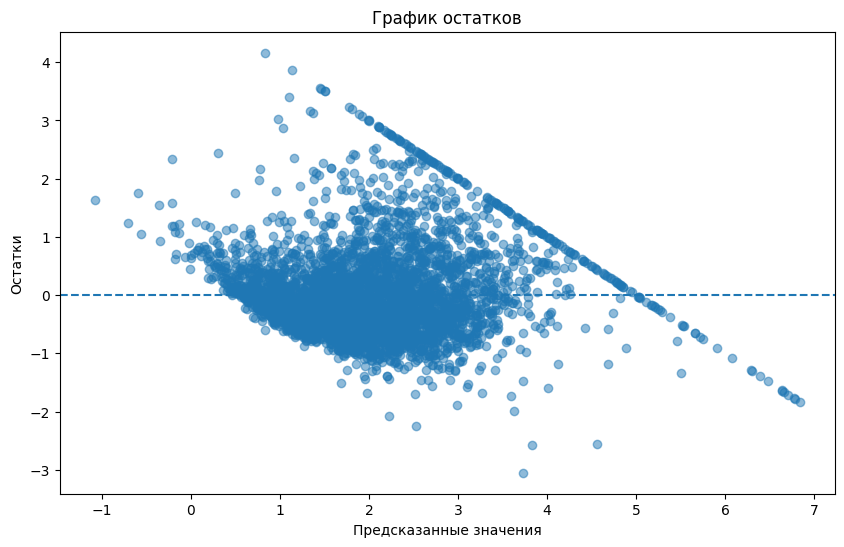

In [ ]:
residuals = y_test_red - y_pred_red

plt.figure(figsize=(10, 6))

plt.scatter(
    y_pred_red,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Предсказанные значения")
plt.ylabel("Остатки")
plt.title("График остатков")

plt.show()

In [ ]:
print("Среднее значение остатков:", residuals.mean())
print("Минимальный остаток:", residuals.min())
print("Максимальный остаток:", residuals.max())


## Вывод

В данной работе была построена базовая модель линейной регрессии с использованием 8 числовых признаков California Housing Dataset. Для оценки качества модели были рассчитаны MAE, MSE, RMSE и R².

Для проверки мультиколлинеарности была построена корреляционная матрица и рассчитан показатель VIF. На основании анализа признаков один из избыточных признаков был удалён, в результате чего количество признаков уменьшилось с 8 до 7.

После сокращения набора признаков была обучена вторая модель. Значение RMSE уменьшилось с 0.7456 до 0.7398, а R² увеличилось с 0.5758 до 0.5823. При этом MAE немного увеличилось с 0.5332 до 0.5425. Таким образом, качество моделей осталось близким, а сокращённая модель использует на один признак меньше.

Также был построен график остатков для проверки наличия систематического паттерна. Распределение остатков относительно нулевой линии позволяет оценить, насколько линейная модель соответствует данным.

В качестве финального набора признаков выбран сокращённый набор из 7 признаков, поскольку он обеспечивает сопоставимое качество предсказания при меньшем количестве признаков.

